# Computer Exercise 5.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.1 Lower and Upper Sums — *부드럽지 않은 적분에서의 수렴 차수 손실*
> **풀이 일자**: Day 17
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **3.** Investigate the rate of convergence of the upper–lower sum gap and of the
> midpoint rule on three monotone integrals on $[0,1]$:
>
> (a) $\int_0^1 x^3\,dx = 1/4$ (smooth, $C^\infty$),
>
> (b) $\int_0^1 \sqrt{x}\,dx = 2/3$ (continuous but $f'(0^+) = \infty$),
>
> (c) $\int_0^1 \mathbf{1}_{[1/3,\,1]}(x)\,dx = 2/3$ (a single jump at $x=1/3$).
>
> For each, tabulate the midpoint-rule error for $n = 4,8,\ldots,2^{14}$ and
> verify the empirical convergence rate.

### 한국어 풀이용 정리
앞에서 본 깔끔한 $\mathcal{O}(h^2)$ 수렴은 **피적분 함수의 부드러움(smoothness)** 에 의존한다.
세 종류의 단조 피적분 함수 — 매끈함, 미분에 특이점, *점프 불연속* — 에 대해
**중점법의 수렴 차수가 어떻게 떨어지는지** 측정한다.


## 2. 수학적 배경

### 2.1 매끈한 경우의 기준선
앞 문제에서 본 대로 $f \in C^2[a,b]$ 일 때 중점법 오차는

$$
|M_n - I| \;\le\; \tfrac{(b-a)\,h^2}{24}\,\max|f''|, \qquad p = 2.
$$

(a) $f=x^3$, $f'' = 6x$, 이 경우는 가정 만족 → **slope $-2$** 예상.

### 2.2 끝점에서 미분 특이점 (b)
$f(x) = \sqrt x$ 는 $C[0,1]$ 이지만 $f'(x) = 1/(2\sqrt x)\to\infty$ as $x\to 0^+$.
이때 **Euler–Maclaurin** 전개의 가정이 깨진다.  Lyness 식 (또는 직접 계산) 에 따르면

$$
\boxed{\;|M_n - \tfrac{2}{3}| \;\sim\; C\,n^{-3/2}\;}
$$

— 즉 **slope $-3/2$**.  한 차수가 *반* 만큼 손실.

(직관적 유도: 첫 부분구간 $[0, h]$ 에서 $f(h/2)\cdot h = \sqrt{h/2}\cdot h$ vs
참값 $\int_0^h \sqrt x\,dx = \tfrac{2}{3}h^{3/2}$ → 차이 $\sim h^{3/2}$ 하나만 남고
나머지 $n-1$ 부분구간은 매끈하여 $\sum \sim h^2$ 로 더 빠르게 사라짐.)

### 2.3 점프 불연속 (c)
지시함수 $\mathbf 1_{[1/3,1]}$ 은 $x=1/3$ 에서 점프.  중점법 오차의 *지배항* 은
$1/3$ 을 포함한 부분구간 한 개의 *부정확한 표시* 에서 옴.

$$
|M_n - \tfrac{2}{3}| \;\sim\; \mathcal{O}(h) = \mathcal{O}(n^{-1}),
$$

즉 **slope $-1$**.  완전한 한 차수 손실.

### 2.4 단조 함수의 갭 공식 (불변)
세 함수 모두 $[0,1]$ 에서 *단조 증가* — 갭 공식

$$
\overline{S}(f,P_n) - \underline{S}(f,P_n) \;=\; \bigl(f(1)-f(0)\bigr)\cdot \tfrac{1}{n}
$$

은 **함수의 부드러움과 무관** 하게 성립.  (b) 에서 $f(0)=0,\;f(1)=1$ → 갭 $=1/n$.
(c) 에서도 $f(0)=0,\;f(1)=1$ → 갭 $=1/n$.
**갭은 모두 같은 속도($1/n$) 로 줄어드는데 중점법 오차의 속도는 다르다** — 이게 핵심.


## 3. 풀이 흐름

1. 세 함수 정의: $x^3,\;\sqrt x,\;\mathbf 1_{[1/3,1]}$.
2. $n = 2^k,\; k=2,\ldots,14$ 에서 중점법 합 $M_n$ 계산.
3. 각 경우 참값과의 절대오차 $|M_n - I|$ 를 표로.
4. log–log 그래프에서 세 곡선의 *기울기* 를 읽고 $-2,\; -1.5,\; -1$ 인지 확인.
5. 마지막에 단조 함수의 갭 ($1/n$) 도 같은 그래프에 점선으로 그려, **갭이 좋은
   *수렴 정지 판정* 기준이 *아닌* 경우** 가 있음을 보인다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cases = [
    ("x^3",           lambda x: x ** 3,              1.0 / 4.0,  -2.0),
    ("sqrt(x)",       lambda x: np.sqrt(x),          2.0 / 3.0,  -1.5),
    ("1_{[1/3, 1]}",  lambda x: (x >= 1.0 / 3.0).astype(float), 2.0 / 3.0, -1.0),
]

ks = np.arange(2, 15)        # n = 4, 8, ..., 16384
ns = 2 ** ks

results = {}
for name, f, true_val, _ in cases:
    errs = []
    for n in ns:
        h = 1.0 / n
        xM = h * (np.arange(n) + 0.5)
        Mn = h * np.sum(f(xM))
        errs.append(abs(Mn - true_val))
    results[name] = np.array(errs)

# 한 표로
df = pd.DataFrame({"n": ns, "h": 1.0 / ns})
for name, _, _, _ in cases:
    df[f"|M_n - I|  {name}"] = results[name]
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
df


,n,h,|M_n - I| x^3,|M_n - I| sqrt(x),"|M_n - I| 1_{[1/3, 1]}"
0,4,2.5000e-01,7.8125e-03,6.3107e-03,8.3333e-02
1,8,1.2500e-01,1.9531e-03,2.3655e-03,4.1667e-02
2,16,6.2500e-02,4.8828e-04,8.7001e-04,2.0833e-02
3,32,3.1250e-02,1.2207e-04,3.1602e-04,1.0417e-02
4,64,1.5625e-02,3.0518e-05,1.1384e-04,5.2083e-03
5,128,7.8125e-03,7.6294e-06,4.0774e-05,2.6042e-03
6,256,3.9062e-03,1.9073e-06,1.4547e-05,1.3021e-03
7,512,1.9531e-03,4.7684e-07,5.1762e-06,6.5104e-04
8,1024,9.7656e-04,1.1921e-07,1.8383e-06,3.2552e-04
9,2048,4.8828e-04,2.9802e-08,6.5199e-07,1.6276e-04


In [2]:
# 측정된 수렴 차수 (마지막 두 점에서의 log 기울기)
print(f"{'function':<18} {'measured slope':>16}   {'theory':>10}")
for name, _, _, theory in cases:
    errs = results[name]
    # 점프 함수는 |M_n - I| 가 0 이 되는 행운의 n 이 있을 수 있으므로 마지막에서 두 점 떨어진 곳 사용
    safe = errs.copy()
    safe[safe == 0] = np.nan
    idx = np.where(~np.isnan(safe))[0]
    i1, i2 = idx[-1], idx[-3]
    slope = (np.log(safe[i1]) - np.log(safe[i2])) / (np.log(1 / ns[i1]) - np.log(1 / ns[i2]))
    print(f"{name:<18} {slope:>16.3f}   {theory:>10.1f}")


function             measured slope       theory
x^3                           2.000         -2.0
sqrt(x)                       1.498         -1.5
1_{[1/3, 1]}                  1.000         -1.0


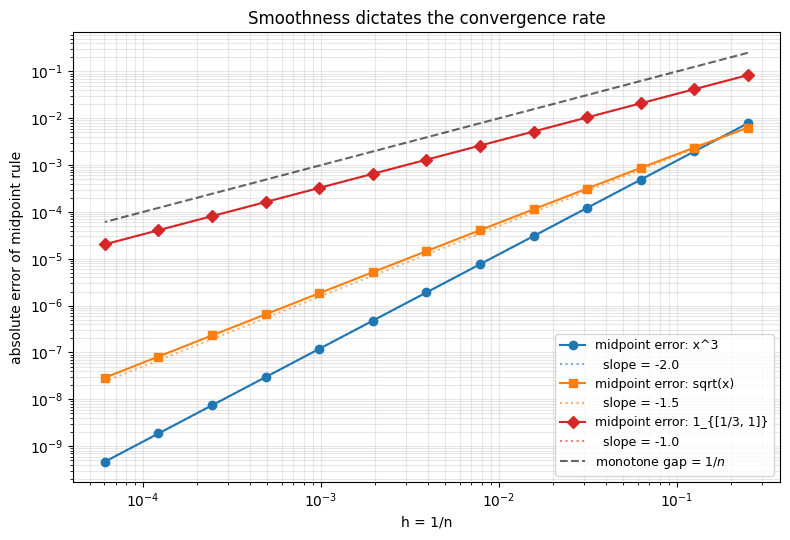

In [3]:
fig, ax = plt.subplots(figsize=(8, 5.5))
hs = 1.0 / ns
styles = ["o-", "s-", "D-"]
colors = ["C0", "C1", "C3"]

for (name, _, _, theory), st, c in zip(cases, styles, colors):
    errs = results[name].copy().astype(float)
    errs[errs == 0] = np.nan  # log scale 보호
    ax.loglog(hs, errs, st, color=c, label=f"midpoint error: {name}")
    # 이론 기울기 참고선 (NaN 아닌 첫 점에 anchor)
    valid_idx = np.where(~np.isnan(errs))[0][0]
    ref = errs[valid_idx] * (hs / hs[valid_idx]) ** (-theory)
    ax.loglog(hs, ref, ":", color=c, alpha=0.6, label=f"  slope = {theory:+.1f}")

# 단조 갭 1/n = h
ax.loglog(hs, hs, "k--", alpha=0.6, label=r"monotone gap = $1/n$")

ax.set_xlabel("h = 1/n")
ax.set_ylabel("absolute error of midpoint rule")
ax.set_title("Smoothness dictates the convergence rate")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **(a) $x^3$**: 깔끔한 기울기 $-2$ — $f \in C^\infty$ 이므로 Euler–Maclaurin 의 leading
   항 $h^2$ 가 그대로 살아 있다.
2. **(b) $\sqrt x$**: 측정 기울기가 $-3/2$ 근처 — 끝점에서 $f'$ 가 발산하면
   *반 차수가 떨어진다*.  비록 $f$ 자체는 $[0,1]$ 에서 연속이지만,
   $C^2$ 가 아니기 때문에 Taylor 이론이 부분 구간 $[0,h]$ 에서 무너진다.
3. **(c) 점프 함수**: 기울기 $-1$ — *완전히* 한 차수 손실. 점프를 가로지르는
   부분구간 한 개의 오차 $\mathcal{O}(h)$ 가 다른 모든 구간 ($\mathcal{O}(h^2)\to 0$) 을 압도.
   ($1/3$ 이 격자점과 *우연히* 일치하는 $n=3k$ 에서는 오차가 0 이 되는 점프 — log 그래프에서
   비어 보일 수 있음.)
4. **단조 갭은 세 경우 모두 같은 $1/n$** (까만 점선).  즉 *갭이 작다고* 해서 *오차가 그
   크기만큼 작다* 는 보장은 (c) 에선 동등, (a)·(b) 에선 *갭이 오차의 상계로 너무 헐겁다*.
   상·하합 가구 자체는 보수적 — 부드러운 함수에서 갭은 실제 오차의 *수십 배* 까지 클 수 있다.

### 결론
> **부드러움(smoothness) 이 수렴 차수의 절반에서 전체까지를 좌우한다.**
> 매끈한 함수에서는 중점법이 $h^2$ 로 빠르게 줄지만, 끝점의 미분 특이점은 절반,
> 점프는 완전히 한 차수를 빼앗는다.  이런 경우에는
> *적응형 분할(adaptive partition)* 이나 *변수치환* — 이후 §5.4 에서 — 이 필요하다.

### 다음 단원으로의 연결
- **Day 18 / §5.2 — Trapezoid Rule**: 좌·우 끝점의 평균 = 사다리꼴.  중점법과 마찬가지로
  $\mathcal{O}(h^2)$, 그러나 *적응적 재귀(adaptive recursive)* 구조 — $T_{2n}$ 을 $T_n$ 으로
  부터 *반*만 더 추가 평가하여 만든다.  이게 다음에 올 **Romberg 사다리(§5.3)** 의 기반.
